In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, BatchNormalization, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall, AUC
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
import joblib, gc

FEATURES_SELECCIONADAS = [
    'iat', 'rst_count', 'urg_count', 'number', 'variance', 'tot_size',
    'max', 'header_length', 'flow_duration', 'weight', 'rate', 'duration',
    'protocol_type', 'syn_flag_number', 'fin_count', 'syn_count',
    'rst_flag_number', 'ack_count'
]
NOMBRE_CLASE_BENIGNA = 'BenignTraffic'

print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))


TF version: 2.10.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
df = pd.read_feather('Z:/TFG-Alvarez_Julian/IDS-IOT/data/df_binary_balanced.feather')
df['label_binario'] = (df['label'] != NOMBRE_CLASE_BENIGNA).astype(int)
print('Shape:', df.shape)
print(df['label_binario'].value_counts())


Shape: (1976752, 48)
label_binario
0    988376
1    988376
Name: count, dtype: int64


In [3]:
X = df[FEATURES_SELECCIONADAS].values
y = df['label_binario'].values

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=2/9, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

del df; gc.collect()

print(f'Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}')
print(f'Features: {X_train.shape[1]}')


Train: 1,383,725  Val: 395,351  Test: 197,676
Features: 18


In [4]:
def focal_loss(gamma=2.0, alpha=0.75):
    """
    Focal Loss binaria.
    gamma > 0 enfoca en ejemplos dificiles.
    alpha = peso clase positiva (malicioso).
    NO combinar con class_weight.
    """
    def _loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1.0 - y_true) * tf.math.log(1.0 - y_pred)
        p_t = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
        alpha_t = y_true * alpha + (1.0 - y_true) * (1.0 - alpha)
        return tf.reduce_mean(alpha_t * tf.pow(1.0 - p_t, gamma) * bce)
    return _loss

# FIX 1 — Instanciar focal_loss UNA SOLA VEZ y reutilizar en todo el notebook.
# focal_loss() es un closure que retorna la funcion interna _loss.
# Reutilizar la misma instancia evita ambiguedad al cargar el modelo y compilar.
loss_fn = focal_loss(gamma=2.0, alpha=0.75)


#### Poda de Magnitud (Weight Pruning)
Se utiliza TensorFlow Model Optimization Toolkit para podar gradualmente los pesos menos importantes durante un reentrenamiento corto

In [8]:
import tensorflow as tf
import tensorflow_model_optimization as tfmot
from qkeras.utils import model_quantize
from tensorflow.keras.optimizers import Adam

# 1. Definir los parámetros de poda (Pruning)
pruning_params = {
    'pruning_schedule': tfmot.sparsity.keras.ConstantSparsity(
        target_sparsity=0.60, # Tu objetivo del 60%
        begin_step=0,
        frequency=100
    )
}

# 2. Definir tu diccionario de cuantización de QKeras (Ajusta según tu topología)
# 2. Diccionario de Cuantización COMPLETO para HLS4ML
qkeras_config = {
    # Cuantización de las capas DENSAS (Pesos y Sesgos)
    "QDense": {
        "kernel_quantizer": "quantized_bits(8, 2, alpha=1)", 
        "bias_quantizer": "quantized_bits(8, 2, alpha=1)"
    },
    # Cuantización de las capas de ACTIVACIÓN explícitas (Tu caso)
    "Activation": {
        "relu": "quantized_relu(8, 2)" # <-- AQUÍ ESTÁN LOS BITS DE ACTIVACIÓN
    },
    # Por si alguna capa densa tiene la activación implícita (ej. activation='sigmoid')
    "QActivation": {
        "relu": "quantized_relu(8, 2)",
        "sigmoid": "quantized_bits(8, 2)"
    }
}


In [10]:
# 1. Cargar o instanciar tu modelo flotante base entrenado
base_model = tf.keras.models.load_model('Z:\TFG-Alvarez_Julian\IDS-IOT\models\mlp_v2\mlp_binario_v2_exp2_focalloss.h5', custom_objects={'_loss': loss_fn})

# 2. Cuantizar el modelo base primero (Crea las capas QDense/QActivation sin entrenar aún)
qat_model = model_quantize(base_model, qkeras_config, activation_bits=(8,2))

# 3. Envolver el modelo QKeras con la máscara de poda de TFMOT
joint_model = tfmot.sparsity.keras.prune_low_magnitude(qat_model, **pruning_params)

# Mostrar la arquitectura combinada
joint_model.summary()

Model: "mlp_binario_v2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 prune_low_magnitude_dense_2  (None, 64)               2370      
 5 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_batch_n  (None, 64)               257       
 ormalization_20 (PruneLowMa                                     
 gnitude)                                                        
                                                                 
 prune_low_magnitude_activat  (None, 64)               1         
 ion_20 (PruneLowMagnitude)                                      
                                                                 
 prune_low_magnitude_dropout  (None, 64)               1         
 _20 (PruneLowMagnitude)                                         
                                                    

In [11]:
# 1. Instanciar el optimizador Adam de forma aislada
optimizer = Adam(learning_rate=1e-4) # Usar un LR menor (fine-tuning)

# 2. Forzar la variable interna de iteraciones a INT32 para evitar el bug de CUDA
optimizer.iterations = tf.Variable(0, dtype=tf.int32, name="iterations")

# 3. Compilar el modelo con tu función custom de Focal Loss
joint_model.compile(
    optimizer=optimizer,
    loss=loss_fn, # Tu función customizada
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

# Definir los callbacks obligatorios
callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep(), # REQUERIDO para mantener los ceros estables
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

with tf.device('/CPU:0'):
    # Entrenamiento consciente de poda y cuantización al mismo tiempo
    history = joint_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=15, # Las 15 épocas que tenías planificadas
        batch_size=128,
        callbacks=callbacks,
        verbose=1
    )

Epoch 1/15
10811/10811 [==============================] - 82s 8ms/step - loss: 0.0836 - auc: 0.9673 - accuracy: 0.9017 - val_loss: 0.0256 - val_auc: 0.9955 - val_accuracy: 0.9888
Epoch 2/15
10811/10811 [==============================] - 80s 7ms/step - loss: 0.0273 - auc: 0.9930 - accuracy: 0.9739 - val_loss: 0.0173 - val_auc: 0.9970 - val_accuracy: 0.9909
Epoch 3/15
10811/10811 [==============================] - 81s 7ms/step - loss: 0.0154 - auc: 0.9949 - accuracy: 0.9890 - val_loss: 0.0111 - val_auc: 0.9972 - val_accuracy: 0.9914
Epoch 4/15
10811/10811 [==============================] - 79s 7ms/step - loss: 0.0105 - auc: 0.9958 - accuracy: 0.9904 - val_loss: 0.0084 - val_auc: 0.9976 - val_accuracy: 0.9915
Epoch 5/15
10811/10811 [==============================] - 79s 7ms/step - loss: 0.0085 - auc: 0.9964 - accuracy: 0.9907 - val_loss: 0.0074 - val_auc: 0.9976 - val_accuracy: 0.9918
Epoch 6/15
10811/10811 [==============================] - 76s 7ms/step - loss: 0.0075 - auc: 0.9967 - acc

In [14]:
# Eliminar las máscaras de entrenamiento y dejar solo los pesos netos comprimidos
final_hardware_model = tfmot.sparsity.keras.strip_pruning(joint_model)

# Guardar el modelo definitivo optimizado para hls4ml
final_hardware_model.save("modelo_binario_pruned_qat_final.h5")

In [15]:
# 4. Evaluacion comparativa: base vs. pruned+QAT
for nombre, modelo in [('Base (sin comprimir)', base_model),
                        ('Pruned + QAT',         qat_model)]:
    probs = modelo.predict(X_test, batch_size=128).ravel()
    preds = (probs > 0.5).astype(int)
    print(f'\n=== {nombre} ===')
    print(classification_report(y_test, preds,
          target_names=['Legitimo (0)', 'Malicioso (1)'], digits=4))


1545/1545 [==============================] - 2s 855us/step

=== Base (sin comprimir) ===
               precision    recall  f1-score   support

 Legitimo (0)     0.9895    0.9987    0.9941     98838
Malicioso (1)     0.9986    0.9894    0.9940     98838

     accuracy                         0.9940    197676
    macro avg     0.9941    0.9940    0.9940    197676
 weighted avg     0.9941    0.9940    0.9940    197676

1545/1545 [==============================] - 3s 2ms/step

=== Pruned + QAT ===
               precision    recall  f1-score   support

 Legitimo (0)     0.9879    0.9981    0.9930     98838
Malicioso (1)     0.9981    0.9878    0.9929     98838

     accuracy                         0.9930    197676
    macro avg     0.9930    0.9930    0.9930    197676
 weighted avg     0.9930    0.9930    0.9930    197676



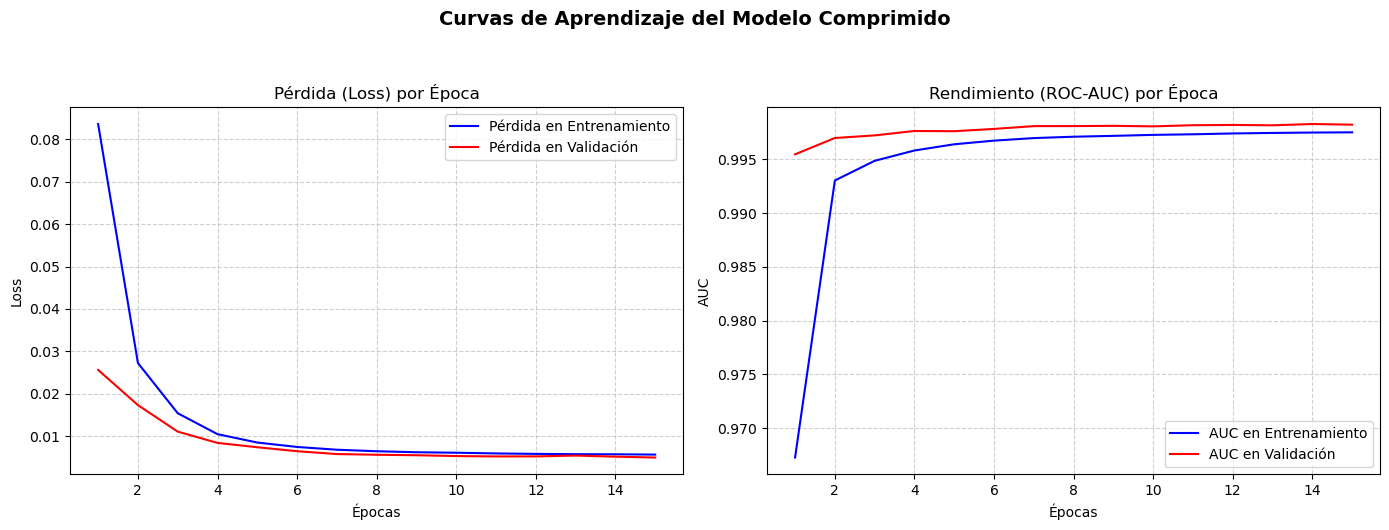

In [17]:
import matplotlib.pyplot as plt

def graficar_curvas_entrenamiento(history, titulo="Curvas de Aprendizaje del Modelo Comprimido"):
    """
    Grafica la función de pérdida (Loss) y la métrica principal (AUC) 
    para los conjuntos de entrenamiento y validación.
    """
    # Extraer datos del historial
    acc = history.history.get('auc') or history.history.get('auc_1') # Dependiendo del nombre en TF
    val_acc = history.history.get('val_auc') or history.history.get('val_auc_1')
    loss = history.history.get('loss') or history.history.get('student_loss')
    val_loss = history.history.get('val_loss') or history.history.get('val_student_loss')

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Gráfico de Pérdida (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'b-', label='Pérdida en Entrenamiento')
    if val_loss:
        plt.plot(epochs, val_loss, 'r-', label='Pérdida en Validación')
    plt.title('Pérdida (Loss) por Época')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Gráfico de Métrica (AUC)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'b-', label='AUC en Entrenamiento')
    if val_acc:
        plt.plot(epochs, val_acc, 'r-', label='AUC en Validación')
    plt.title('Rendimiento (ROC-AUC) por Época')
    plt.xlabel('Épocas')
    plt.ylabel('AUC')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.suptitle(titulo, fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# Ejecución:
graficar_curvas_entrenamiento(history)


📊 EVALUACIÓN: Base (Punto Flotante)
--- Análisis de Hardware: Base (Punto Flotante) ---
🔹 Parámetros Totales:   21,057
🔹 Parámetros Activos:   21,057 (Sparsity: 0.00%)
🔹 Tipo de Dato (Aprox): FP-32 (4 bytes)
⚡ Huella en Memoria BRAM (Aprox): 82.25 KB

⭐ ROC-AUC Score: 0.9986
----------------------------------------------------------------------
               precision    recall  f1-score   support

 Legítimo (0)     0.9895    0.9987    0.9941     98838
Malicioso (1)     0.9986    0.9894    0.9940     98838

     accuracy                         0.9940    197676
    macro avg     0.9941    0.9940    0.9940    197676
 weighted avg     0.9941    0.9940    0.9940    197676



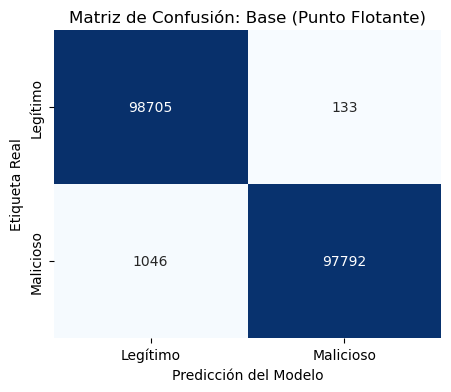


📊 EVALUACIÓN: Pruned + QAT (Sparsity 60% + 8-bits)
--- Análisis de Hardware: Pruned + QAT (Sparsity 60% + 8-bits) ---
🔹 Parámetros Totales:   21,057
🔹 Parámetros Activos:   9,284 (Sparsity: 55.91%)
🔹 Tipo de Dato (Aprox): INT-8 (1 byte)
⚡ Huella en Memoria BRAM (Aprox): 9.07 KB

⭐ ROC-AUC Score: 0.9981
----------------------------------------------------------------------
               precision    recall  f1-score   support

 Legítimo (0)     0.9879    0.9981    0.9930     98838
Malicioso (1)     0.9981    0.9878    0.9929     98838

     accuracy                         0.9930    197676
    macro avg     0.9930    0.9930    0.9930    197676
 weighted avg     0.9930    0.9930    0.9930    197676



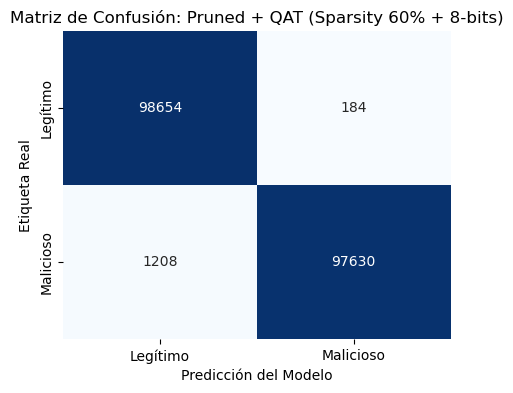

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def analizar_parametros_hardware(modelo, nombre):
    """Cuenta parámetros totales, activos (no nulos) y estima huella de memoria."""
    total_params = 0
    active_params = 0
    
    for layer in modelo.layers:
        pesos = layer.get_weights()
        for p in pesos:
            total_params += np.size(p)
            active_params += np.count_nonzero(p)
            
    sparsity = 1.0 - (active_params / total_params) if total_params > 0 else 0
    
    # Estimación simple de memoria:
    # Punto flotante original = 32 bits (4 bytes). Modelo QAT = 8 bits (1 byte)
    es_cuantizado = "QAT" in nombre or "Estudiante" in nombre
    bytes_por_parametro = 1 if es_cuantizado else 4
    
    huella_kb = (active_params * bytes_por_parametro) / 1024
    
    print(f"--- Análisis de Hardware: {nombre} ---")
    print(f"🔹 Parámetros Totales:   {total_params:,}")
    print(f"🔹 Parámetros Activos:   {active_params:,} (Sparsity: {sparsity:.2%})")
    print(f"🔹 Tipo de Dato (Aprox): {'INT-8 (1 byte)' if es_cuantizado else 'FP-32 (4 bytes)'}")
    print(f"⚡ Huella en Memoria BRAM (Aprox): {huella_kb:.2f} KB\n")

def evaluar_y_comparar_modelos(dict_modelos, X_test, y_test):
    """
    Evalúa modelos, compara métricas y analiza su impacto en hardware.
    """
    for nombre, modelo in dict_modelos.items():
        print(f"\n{'='*70}")
        print(f"📊 EVALUACIÓN: {nombre}")
        print(f"{'='*70}")
        
        # 1. Perfilado de Hardware
        analizar_parametros_hardware(modelo, nombre)
        
        # 2. Inferencia
        probs = modelo.predict(X_test, batch_size=512, verbose=0).ravel()
        preds = (probs > 0.5).astype(int)
        
        # 3. Métricas
        auc_score = roc_auc_score(y_test, probs)
        print(f"⭐ ROC-AUC Score: {auc_score:.4f}")
        print("-" * 70)
        print(classification_report(y_test, preds, target_names=['Legítimo (0)', 'Malicioso (1)'], digits=4))
        
        # 4. Matriz de Confusión
        cm = confusion_matrix(y_test, preds)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                    xticklabels=['Legítimo', 'Malicioso'],
                    yticklabels=['Legítimo', 'Malicioso'])
        plt.title(f'Matriz de Confusión: {nombre}')
        plt.ylabel('Etiqueta Real')
        plt.xlabel('Predicción del Modelo')
        plt.show()


evaluar_y_comparar_modelos({
    "Base (Punto Flotante)": base_model,
    "Pruned + QAT (Sparsity 60% + 8-bits)": qat_model
}, X_test, y_test)

In [19]:
# 5. Guardar modelo final para hls4ml
qat_model.save('modelo_qat_pruned.h5')

with open('modelo_qat_pruned_arch.json', 'w') as f:
    f.write(qat_model.to_json())
qat_model.save_weights('modelo_qat_pruned_weights.h5')

print('Guardado: modelo_qat_pruned_qat.h5')
print('Guardado: modelo_qat_pruned_arch.json')
print('Guardado: modelo_qat_pruned_weights.h5')


Guardado: modelo_qat_pruned_qat.h5
Guardado: modelo_qat_pruned_arch.json
Guardado: modelo_qat_pruned_weights.h5
